# Linear discriminant analysis


In [34]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

## Exercise 1: train LDA
1. Write the function `train_lda(X, y)` that accepts the data $\mathbf{X}\in\mathbb{R}^{N \times D}$ of $N$ examples and $D$ features and the labels $\mathbf{y}\in\mathbb{N}^N$ containing integer class labels, one for each example. The function should output the `weights` and `bias`. Note, we assume a binary classification problem.

In [35]:
# Answer here
def train_lda(X,y):
    classes = np.unique(y)
    X0 = X[y == classes[0]]
    X1 = X[y == classes[1]]
    X0m = np.mean(X0,axis=0)
    X1m = np.mean(X1,axis=0)
    cov_matrix_class_0 = np.cov(X0,rowvar=False)
    cov_matrix_class_1 = np.cov(X1,rowvar=False)
    Sw = (cov_matrix_class_0 + cov_matrix_class_1)/2
    w=(np.linalg.inv(Sw))@(X1m-X0m)
    b = -((np.transpose(w)) @ (X1m + X0m)) / 2
    return w,b



w,b = train_lda(X,y)
    
    

## Exercise 2: apply LDA
1. Write the function `apply_lda(X, weights, bias)` to apply a trained LDA (given by `weights` and `bias`) to new data (i.e., validation/test data) $\mathbf{X}\in\mathbb{R}^{N \times D}$. The output should be predicted class labels $\mathbf{\hat{y}}\in\mathbb{N}^N$ containing integer class labels, one for each example.

In [36]:
# Answer here
def apply_lda(X, weights, bias):
    y = X@weights+bias 
    y = y > 0
    y = y.astype(int)
    return y 

y = apply_lda(X,weights,bias)
    

## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We will restrict the dataset to only two classes.

1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

In [37]:
# Load Iris dataset
iris = datasets.load_iris()
labels = [1, 2]  # subselect 2 classes
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1])
X = iris.data[idx, :]
y = iris.target[idx]

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])
print("Number of features: ", X_train.shape[1])
print("Number of features: ", y_valid)


Number of train examples:  80
Number of valid examples:  20
Number of features:  4
Number of features:  [2 2 2 1 1 1 1 2 1 1 1 1 2 1 2 1 2 2 1 1]


In [38]:
# Answer here
weights,bias = train_lda(X_train,y_train)
y_predicted = apply_lda(X_valid,weights,bias)
classes = np.unique(y_train)
y_predicted = np.where(y_predicted == 0, classes[0], classes[1]) 
predictions = (y_predicted == y_valid)
predictions = predictions.astype(int)
final_mean = np.mean(predictions)
print(classes)
print(final_mean)


model = LDA()
model.fit(X_train, y_train)
final_model_mean = model.score(X_valid, y_valid)

print(final_model_mean)

[1 2]
0.8
0.8


## Exercise 4: preprocess features
In the following data, LDA's linearity assumption is violated. 

1. How can the features be preprocessed to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 75.00


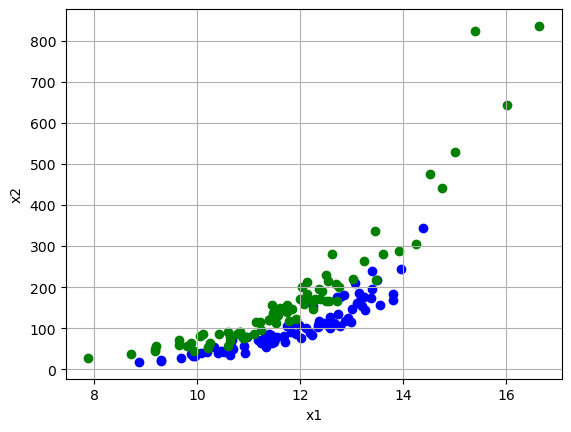

In [39]:
def make_nonlin_data(N, seed=42):
    rng = np.random.default_rng(seed)
    params = {
        0: dict(slope=0.472, intercept=-1.127, resid=0.176),
        1: dict(slope=0.425, intercept=-0.094, resid=0.160),
    }
    n0 = N // 2
    n1 = N - n0
    def sample(n, p):
        x = rng.normal(12.0, 1.6, n)
        x = np.clip(x, 7.0, 16.7)
        log_y = p["slope"] * x + p["intercept"] + rng.normal(0, p["resid"], n)
        return np.column_stack([x, np.exp(log_y)])
    X = np.vstack([sample(n0, params[0]), sample(n1, params[1])])
    labels = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], labels[idx]

# generate data
X, y = make_nonlin_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print(f'Accuracy validation: {score:.2f}')






0.9


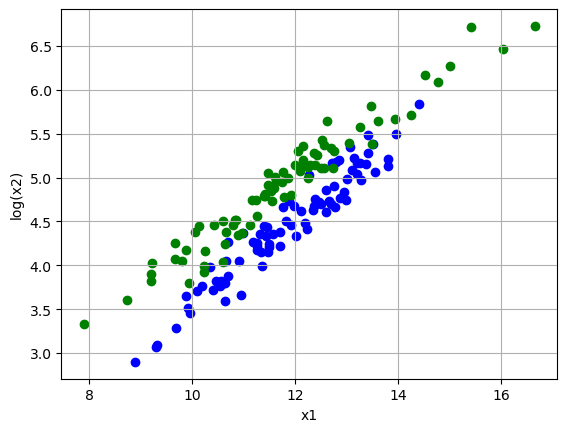

In [44]:
# Answer here
#Apply a logarithmic transformation to the second feature because it was generated exponentially. 
#This should make the relationship between the two features approximately linear and therefore more suitable for LDA.

feature_1_train = X_train[:,0]
feature_2_train_lin = np.log(X_train[:,1])
feature_1_valid = X_valid[:,0]
feature_2_valid_lin = np.log(X_valid[:,1])

X_pre_proccesed_train = np.column_stack((feature_1_train, feature_2_train_lin))
X_pre_proccesed_valid = np.column_stack((feature_1_valid, feature_2_valid_lin))

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_pre_proccesed_train[y_train == 0, 0], X_pre_proccesed_train[y_train == 0, 1], color='b')
plt.scatter(X_pre_proccesed_train[y_train == 1, 0], X_pre_proccesed_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('log(x2)')
plt.grid()


model_v2 = LDA()
model_v2.fit(X_pre_proccesed_train, y_train)
final_model_mean_v2 = model_v2.score(X_pre_proccesed_valid, y_valid)
print(final_model_mean_v2)

# 15% total jump in accuracy!

## Exercise 5: combine features
In the following dataset, in its original form, LDA is not able to perform classification.

1. How can the existing features be combined to get a proper dataset? 
1. Implement your feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 37.50%


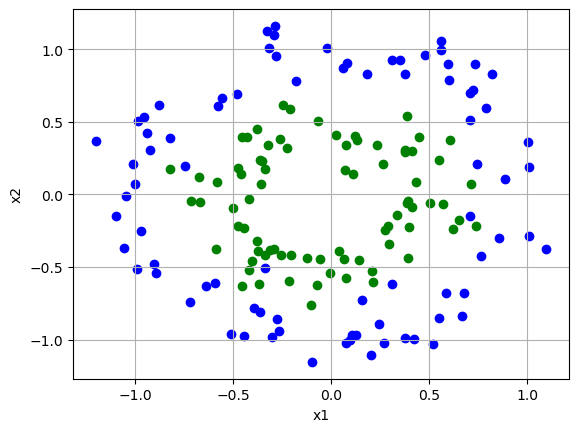

In [45]:
def make_circles_data(N, inner_radius=0.5, outer_radius=1.0, noise=0.13, seed=42):
    rng = np.random.default_rng(seed)
    n_out = N // 2
    n_in = N - n_out
    def ring(n, radius):
        theta = rng.uniform(0, 2 * np.pi, n)
        pts = np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])
        return pts + rng.normal(0, noise, (n, 2))
    X = np.vstack([ring(n_out, outer_radius), ring(n_in, inner_radius)])
    y = np.concatenate([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_circles_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


Accuracy validation: 100.00%


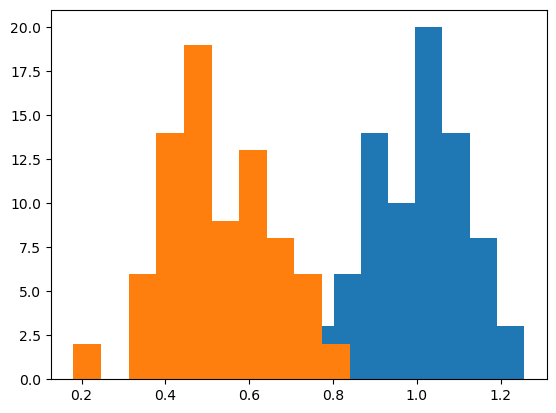

In [52]:
# Answer here
feature_1_train = X_train[:, 0]
feature_2_train = X_train[:, 1]
feature_1_valid = X_valid[:, 0]
feature_2_valid = X_valid[:, 1]

radius_train = np.sqrt(feature_1_train**2 + feature_2_train**2)
radius_valid = np.sqrt(feature_1_valid**2 + feature_2_valid**2)

plt.figure()
plt.hist(radius_train[y_train == 0])
plt.hist(radius_train[y_train == 1])

X_pre_proccesed_train_r = np.column_stack((feature_1_train, feature_2_train,radius_train))
X_pre_proccesed_valid_r = np.column_stack((feature_1_valid, feature_2_valid,radius_valid))

# classify processed data
clf_v2 = LDA()
clf_v2.fit(X_pre_proccesed_train_r, y_train)
score = clf_v2.score(X_pre_proccesed_valid_r, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


#Combining x1 and x2 into the radial feature r=sqrt({x1^2+x2^2}) transforms the nonlinear circular structure into a representation that is much easier for LDA to classify. 
#In this dataset, validation accuracy improved from about 35% to 100%.


## Exercise 6: other LDA-like algorithms
The dataset below again violates an assumption of LDA.

1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? 
1. Inspect QDA and use `QDA()` to improve classification of this dataset.

Accuracy validation: 92.50%


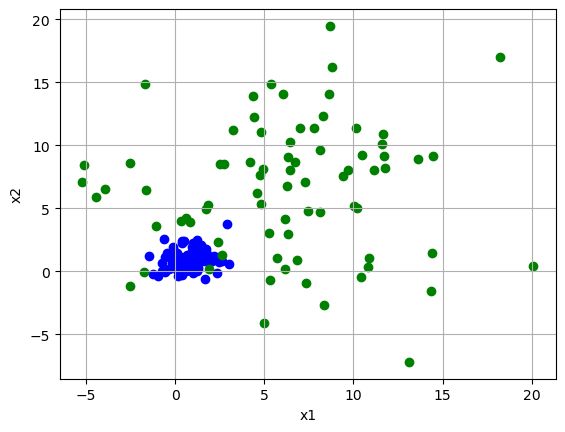

In [53]:
def make_unbalanced_data(N, seed=42):
    rng = np.random.default_rng(seed)
    n0 = N // 2
    n1 = N - n0
    c0 = rng.normal(loc=[0.8, 1.0], scale=[1.05, 0.95], size=(n0, 2))
    c1 = rng.normal(loc=[6.0, 6.8], scale=[4.85, 5.45], size=(n1, 2))
    X = np.vstack([c0, c1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_unbalanced_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


In [54]:
# Answer here
#1)LDA's equal-covariance assumption is violated. 
#Class 0 is tightly distributed while class 1 has much larger variance, so the two classes have substantially different covariance matrices.
#2)A quadratic decision boundary would be more appropriate.

# classify un-processed data WITH QDA
clf_q = QDA()
clf_q.fit(X_train, y_train)
score = clf_q.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))

Accuracy validation: 97.50%
